**LUMP SUM vs DCA**

Mediante este análisis, comprobaremos que técnica de inversión habría sído más rentable si 
hubiesemos invertido un monto total de 10000€ a partir el 1 de enero de 2020 y hasta el 1 de diciembre de 2024, siguiento 3 técnicas distintas: 

* TÉCNICA 1: Invertir todo de golpe en la fecha de inversión inicial **(Lump Sum)**
Se calcula la ganancia neta en el mes de diciembre de 2024, tras haber invertido el monto de inversión al 
completo en la fecha inicial (1 Jan 2020).

* TÉCNICA 2: Invertir una cantidad fija cada cierto perido **(DCA - Dollar Cost Averaging)**
Creamos la columna 'DCA_año', que contiene la ganancia neta tras invertir una vez al año 
desde enero de 2020 hasta enero de 2024, calculando la ganancia neta en el mes de diciembre de 2024.

* TÉCNICA 3: Invertir una cantidad fija cada cierto perido **(DCA - Dollar Cost Averaging)**
Creamos la columna 'DCA_mes', que contiene la ganancia neta tras invertir una vez al mes 
desde enero de 2020 hasta diciembre de 2024, calculando la ganancia neta en el mes de diciembre de 2024.

Para estas funciones hemos creado una funcion 'inversion', que calcula la ganancia neta de la inversión en función de la técnica usada. El parámetro que varía según modalidad es 'periodo_en_meses', el número de meses que transcurre entre periodos: 60 (len(columns)) para Lump Sum, 12 para el DCA anual, y 1 para el DCA mensual. Tras esto, se genera una gráfica de tipo pastel para visualizar los resultados.

En una segunda parte, a partir del excel 'Volatilidad_rentabilidad', se divide la Rentabilidad de los últimos 5 años de cada acción en tres cuantiles = 'ALTA', 'MEDIA' y 'BAJA'. Por último, se evalúa para cada una de estas rentabilidades, el número de acciones con cada técnica. De esta manera, se visualiza mediante un diagrama de barras la efectividad de las técnicas según la rentabilidad de la acción.

In [1]:
import pandas as pd

In [ ]:
# Leemos los dos archvos procedentes del Web Scrapping
df = pd.read_excel('../data/Datos_Acciones.xlsx', header=0, index_col=None)

# Eliminamos las filas no tienen valores desde el 1 de enero del 2020
df = df.dropna(subset=['1 Jan 2020'], how='any').reset_index(drop=True)

In [3]:
# Monto de inversión = 10.000 €
monto_total = 10000

# Columnas con los meses de valores de las acciones
columnas = df.loc[:, '1 Jan 2020':'1 Dec 2024'].columns

In [4]:
# Función para calcular el tipo de inversión
def inversion(fila, columns, monto, periodo_en_meses) -> float:
    # Valor de la inversión parcial en función del número de periodos (en meses)
    inversion_parcial = monto / (len(columns)/periodo_en_meses)
    acciones = 0
    for i in range(0,len(columns), periodo_en_meses): 
        precio = fila[columns[i]]
        acciones += inversion_parcial / precio

    # Calcular el valor final de las acciones
    valor_final = acciones * fila[columns[-1]]

    return valor_final - monto

# TÉCNICA 1: Lump Sum

df['lump_sum'] = df.apply(lambda x: inversion(x, columnas, monto_total, len(columnas)), axis=1)


# TÉCNICA 2: DCA - Dollar Cost Averaging (anual)

df['DCA_año'] = df.apply(lambda x: inversion(x, columnas, monto_total, 12), axis=1)


# TÉCNICA 3: DCA - Dollar Cost Averaging (mensual)
df['DCA_mes'] = df.apply(lambda x: inversion(x, columnas, monto_total, 1), axis=1)

In [5]:
# Creamos columna 'mayor_ganancia', que contiene el nombre de la técnica que aporta una mayor ganancia neta para cada acción
df['mayor_ganancia'] = df[['DCA_mes', 'DCA_año', 'lump_sum']].idxmax(axis=1)
cuenta = df['mayor_ganancia'].value_counts()

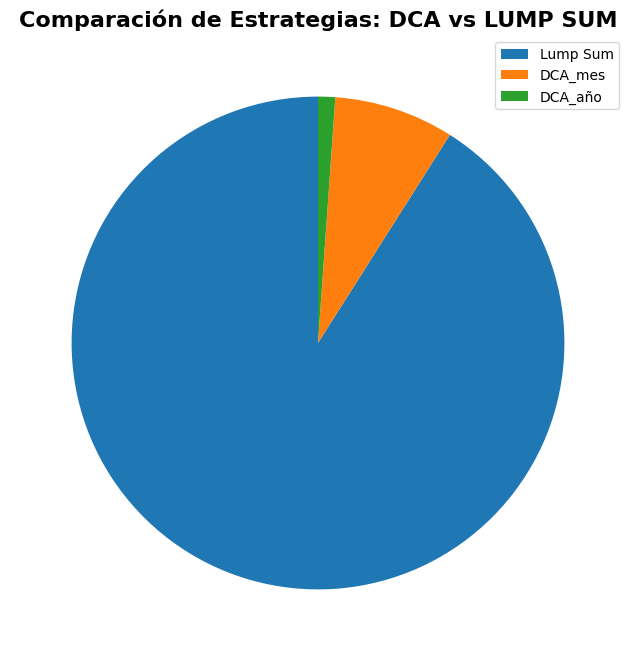

In [6]:
import matplotlib.pyplot as plt

# Crear la gráfica
plt.figure(figsize=(8, 8))  
cuenta.plot(
    kind = 'pie',
    autopct = None, 
    labels = None,
    startangle=90
)

# Título del gráfico
plt.title('Comparación de Estrategias: DCA vs LUMP SUM', fontsize=16, weight='bold')

# Eliminar la etiqueta del eje
plt.ylabel('')

# Añadir leyenda
plt.legend(labels=['Lump Sum', 'DCA_mes', 'DCA_año'], loc='best')

# Mostrar la gráfica
plt.show()


In [ ]:
# Cargamos un excel que analiza la rentabilidad y la volatilidad de cada acción
df_acciones = pd.read_excel('../data/Volatilidad_rentabilidad.xlsx', header= [0,1], index_col=0)

# Ajustamos, a través del nombre de la acción, las filas de df_acciones a las filas del dataframe 'df'
df_acciones = df_acciones[df_acciones[('ACCIÓN', 'Acción')].isin(df['Acción'])].reset_index(drop=True)

# Dividimos la Rentabilidad de los últimos 5 años en 3 cuantiles, y asignamos a la columna '5_años_total' 
# el cuantil al que pertenecen con su correspondiente etiqueta
df_acciones[('RENTABILIDAD','5_años_total')] = pd.qcut(df_acciones[('RENTABILIDAD','Rentabilidad 5 años')], q=3, labels=['BAJA', 'MEDIA', 'ALTA'])

# Añadimos a df_acciones la columna 'mayor_ganancia' del df principal
df_acciones['mayor_ganancia'] = df['mayor_ganancia']

In [8]:
# Contrastamos cada una de las técnicas con la rentabilidad media de los últimos 5 años de las acciones correspondientes
rent_5años = df_acciones.groupby(('RENTABILIDAD', '5_años_total'))['mayor_ganancia'].value_counts()
rent_5años = rent_5años.unstack()

C:\Users\danie\AppData\Local\Temp\ipykernel_2604\877784777.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rent_5años = df_acciones.groupby(('RENTABILIDAD', '5_años_total'))['mayor_ganancia'].value_counts()


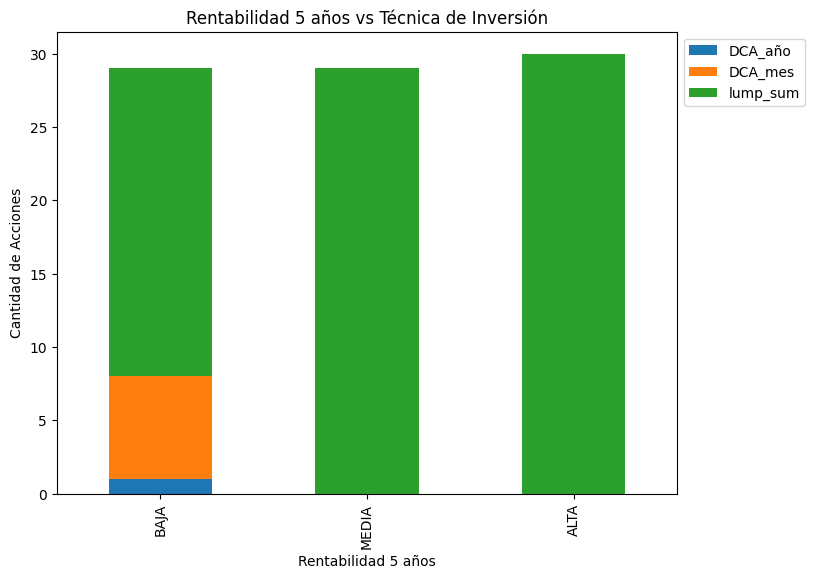

In [9]:
# Crear la gráfica
ax = rent_5años.plot(
    kind='bar', 
    stacked=True, 
    figsize=(8, 6)
)

# Título y etiquetas
plt.title('Rentabilidad 5 años vs Técnica de Inversión')
plt.xlabel('Rentabilidad 5 años')
plt.ylabel('Cantidad de Acciones')

# Mover la leyenda fuera del gráfico
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))

# Mostrar la gráfica
plt.show()
